# Solar-wind context and multi-mission geometry for the May 2024 Gannon storm

The other PyHC winter-school notebooks examine individual boundaries, waves, and timing signatures during the May 2024 Gannon storm. This notebook steps back and asks a more basic set of questions:

1. What were the upstream solar wind and geomagnetic conditions?
2. How much did a pressure-dependent magnetopause model move?
3. Where were THEMIS/ARTEMIS, MMS, GOES-18, and Arase relative to Earth and the modeled boundary?
4. How does the global geometry change our interpretation of the focused event notebooks?

The notebook is deliberately a **context exercise**, not a validation of the T96 magnetopause or magnetic-field model. We use 1-minute OMNI data, GFZ Kp, Kyoto Dst, mission ephemerides, `mpause_t96`, and `tplotxy3`.

> **Coordinate note.** The spacecraft trajectories below are plotted in GSE, as requested. `mpause_t96` is formally a GSM model. Because its pressure-only boundary is rotationally symmetric about the Sun--Earth line, we use it as a useful approximate overlay and label that approximation explicitly. For precise boundary membership or field-line tracing, transform the positions to GSM first.

## Related PyHC winter-school notebooks

This notebook provides the global solar-wind, geomagnetic, and spacecraft-location context for several more focused analyses of the May 2024 Gannon storm:

- [Extreme magnetopause compression observed by THEMIS-A](https://colab.research.google.com/github/spedas/pyspedas_examples/blob/master/pyspedas_examples/notebooks/pyhc_winter_school_2027/themis_gannon_magnetopause_compression.ipynb)
  Examines the exceptionally compressed dayside magnetopause using THEMIS magnetic-field and plasma measurements, upstream observations, and ground magnetometers.

- [Following an extraordinary IMF $B_Y$ flip through geospace](https://colab.research.google.com/github/spedas/pyspedas_examples/blob/master/pyspedas_examples/notebooks/pyhc_winter_school_2027/ohtani_gannon_imf_by_ground_timing.ipynb)
  Tracks a large IMF $B_Y$ reversal from ARTEMIS and OMNI through MMS and GOES-18 to the ground magnetic response, emphasizing timing, cadence, coordinates, and propagation delays.

- [ARTEMIS boundary analysis with minimum variance analysis](https://colab.research.google.com/github/spedas/pyspedas_examples/blob/master/pyspedas_examples/notebooks/pyhc_winter_school_2027/artemis_gannon_mva_boundary_analysis.ipynb)
  Uses ARTEMIS-2 magnetic-field and ion-velocity data to construct a local minimum-variance coordinate system and examine a sharp boundary structure near lunar distance.

- [MMS at an extremely compressed reconnecting magnetopause](https://colab.research.google.com/github/spedas/pyspedas_examples/blob/master/pyspedas_examples/notebooks/pyhc_winter_school_2027/mms_gannon_dayside_reconnection.ipynb)
  Combines MMS2 burst-mode fields, plasma moments, particle spectra, and electric fields to investigate a reconnecting dayside magnetopause compressed to about $7\,R_E$.

- [High-frequency EMIC waves observed by Arase](https://colab.research.google.com/github/spedas/pyspedas_examples/blob/master/pyspedas_examples/notebooks/pyhc_winter_school_2027/arase_gannon_high_frequency_emic_waves.ipynb)
  Introduces the Arase wave event, constructs a gap-aware magnetic power spectrum, and compares the observed wave bands with local H$^+$, He$^+$, and O$^+$ gyrofrequencies.

- [Polarization analysis of the Arase high-frequency EMIC waves](https://colab.research.google.com/github/spedas/pyspedas_examples/blob/master/pyspedas_examples/notebooks/pyhc_winter_school_2027/arase_gannon_emic_wave_polarization.ipynb)
  Extends the introductory Arase analysis by rotating the waveform into mean-field-aligned coordinates and calculating wave power, polarization, ellipticity, helicity, and wave-normal angle.

## 1. Imports, cache directories, and the shared context interval

The interval begins before the THEMIS-A compression on 10 May and ends after the Arase wave interval just after midnight on 12 May. PySPEDAS caches downloaded files, so later runs should be much faster.

In [1]:
# This line makes the notebook portable to Google Colab. Comment it out or skip it
# when the environment already has PySPEDAS 2.2.0 or newer.

!pip install "pyspedas>=2.2.0"

In [2]:
%matplotlib inline

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pyspedas
from pyspedas import *


pyspedas.version()

01-Oct-26 11:26:49: pyspedas version: 2.2.0


In [3]:
context_trange = ["2024-05-10/16:00", "2024-05-12/00:15"]

# Exact teaching intervals reused from the other winter-school notebooks.
events = {
    "THEMIS compression": ["2024-05-10/16:50", "2024-05-10/17:30"],
    "ARTEMIS boundary / IMF By": ["2024-05-10/22:10", "2024-05-10/23:10"],
    "MMS dayside crossing": ["2024-05-11/14:40:40", "2024-05-11/14:46:40"],
    "Arase EMIC waves": ["2024-05-11/23:55", "2024-05-12/00:06"],
}

event_colors = {
    "THEMIS compression": "red",
    "ARTEMIS boundary / IMF By": "purple",
    "MMS dayside crossing": "green",
    "Arase EMIC waves": "orange",
}

context_trange, events

(['2024-05-10/16:00', '2024-05-12/00:15'],
 {'THEMIS compression': ['2024-05-10/16:50', '2024-05-10/17:30'],
  'ARTEMIS boundary / IMF By': ['2024-05-10/22:10', '2024-05-10/23:10'],
  'MMS dayside crossing': ['2024-05-11/14:40:40', '2024-05-11/14:46:40'],
  'Arase EMIC waves': ['2024-05-11/23:55', '2024-05-12/00:06']})

## 2. Upstream solar wind and geomagnetic indices

The OMNI high-resolution product has already been propagated to the bow-shock nose. We request the GSE IMF components, proton bulk speed, proton number density, and solar-wind dynamic pressure.

For 2024, the PySPEDAS `noaa_load_kp` interface automatically uses the definitive GFZ Kp file. Dst is supplied by the World Data Center for Geomagnetism, Kyoto. Kp is a 3-hour planetary activity index; Dst is an hourly measure of the low-latitude disturbance field. Their cadences are much coarser than OMNI's one-minute samples, so do not read minute-scale timing from them.

In [4]:
omni_vars = pyspedas.projects.omni.data(
    trange=context_trange,
    datatype="1min",
    level="hro",
    varnames=["BY_GSE", "BZ_GSE", "flow_speed", "proton_density", "Pressure"],
    time_clip=True,
)

kp_vars = pyspedas.projects.noaa.noaa_load_kp(
    trange=context_trange.copy(),
    datatype=["Kp"],
    gfz=True,
    time_clip=True,
)

dst_vars = pyspedas.projects.kyoto.dst(
    trange=context_trange,
    time_clip=True,
)

print("OMNI:", omni_vars)
print("GFZ Kp:", kp_vars)
print("Kyoto Dst:", dst_vars)

01-Oct-26 11:26:49: Downloading remote index: https://spdf.gsfc.nasa.gov/pub/data/omni/omni_cdaweb/hro_1min/2024/
01-Oct-26 11:26:51: File is current: omni_data/hro_1min/2024/omni_hro_1min_20240501_v01.cdf
01-Oct-26 11:26:51: Loading geomagnetic index data from https://datapub.gfz-potsdam.de/download/10.5880.Kp.0001/Kp_definitive/
01-Oct-26 11:26:52: File is current: geom_indices/Kp_def2024.wdc
01-Oct-26 11:26:53: Remote file not found: http://wdc.kugi.kyoto-u.ac.jp/dst_final/202405/index.html
01-Oct-26 11:26:53: No local files found for http://wdc.kugi.kyoto-u.ac.jp/dst_final/202405/index.html
01-Oct-26 11:26:53: Error occurred while downloading: http://wdc.kugi.kyoto-u.ac.jp/dst_final/202405/index.html
01-Oct-26 11:26:54: File is current: pydata/geom_indices/kyoto/dst_provisional/202405/index.html
01-Oct-26 11:26:54: 
            ******************************
            The DST data are provided by the World Data Center for Geomagnetism, Kyoto, and
            are not for redistrib

OMNI: ['BY_GSE', 'BZ_GSE', 'flow_speed', 'proton_density', 'Pressure']
GFZ Kp: ['Kp']
Kyoto Dst: ['kyoto_dst']


01-Oct-26 12:28:03: Setting coordinate system for BY_GSE
01-Oct-26 12:28:03: Setting units for BY_GSE
01-Oct-26 12:28:03: Setting coordinate system for BZ_GSE
01-Oct-26 12:28:03: Setting units for BZ_GSE


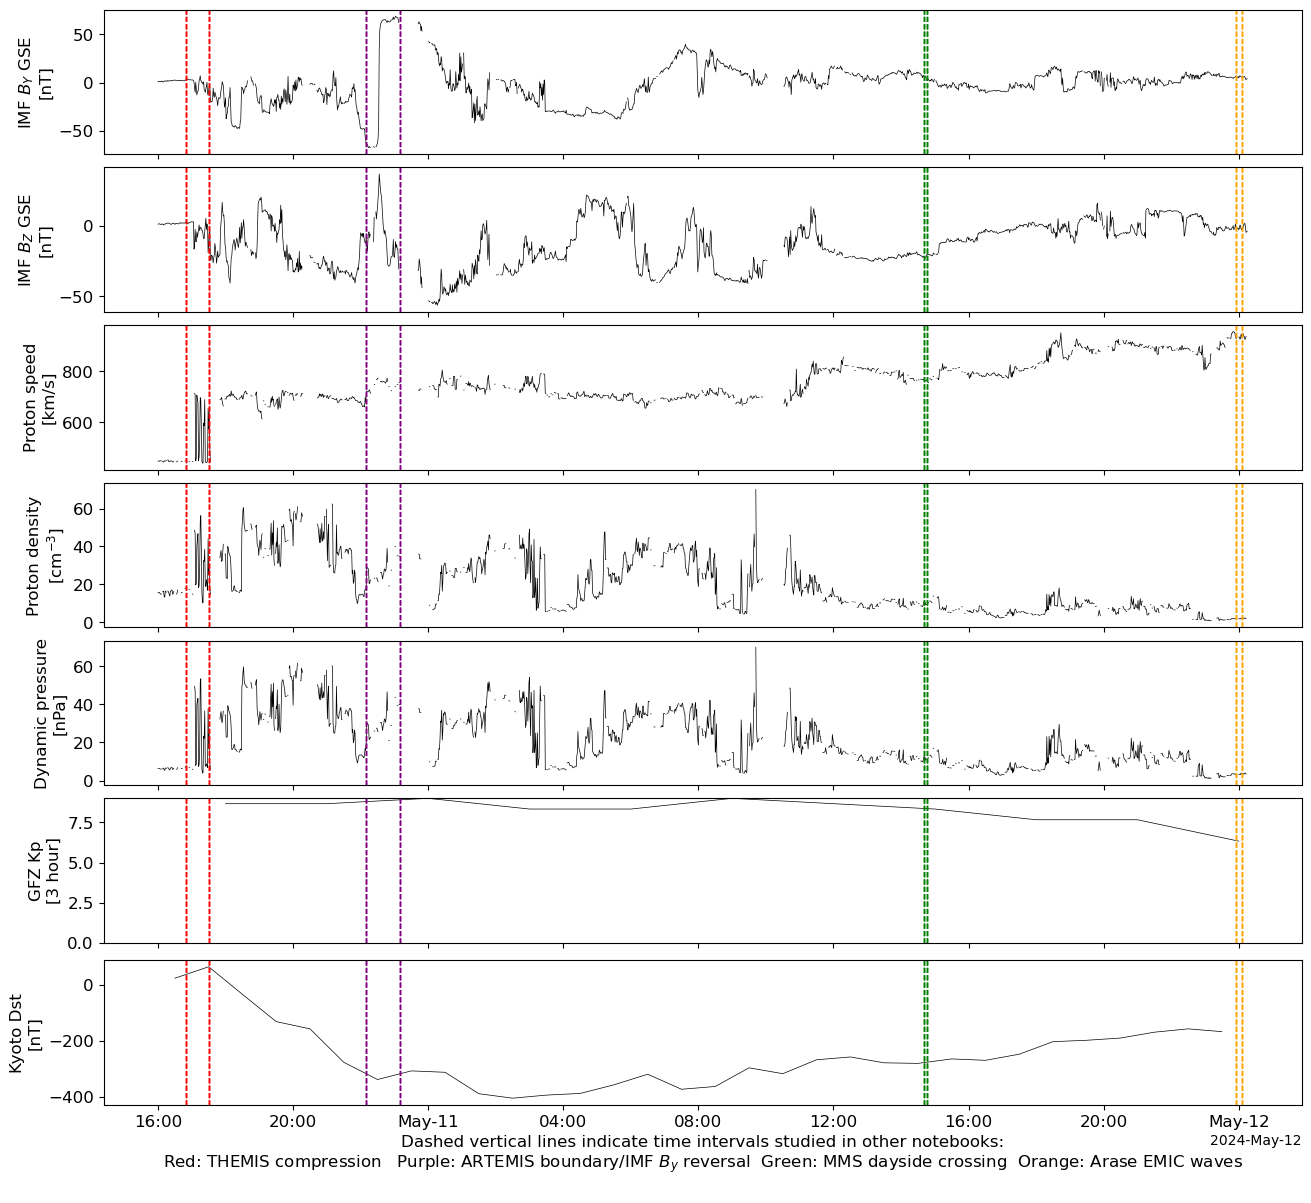

In [21]:
required_context = [
    "BY_GSE", "BZ_GSE", "flow_speed", "proton_density", "Pressure",
    "Kp", "kyoto_dst",
]
missing = [name for name in required_context if get_data(name) is None]
if missing:
    raise RuntimeError(f"Missing expected context variables: {missing}")

for name in ["BY_GSE", "BZ_GSE"]:
    set_coords(name, "GSE")
    set_units(name, "nT")

labels = {
    "BY_GSE": ("IMF $B_Y$ GSE", "[nT]"),
    "BZ_GSE": ("IMF $B_Z$ GSE", "[nT]"),
    "flow_speed": ("Proton speed", "[km/s]"),
    "proton_density": ("Proton density", "[cm$^{-3}$]"),
    "Pressure": ("Dynamic pressure", "[nPa]"),
    "Kp": ("GFZ Kp", "[3 hour]"),
    "kyoto_dst": ("Kyoto Dst", "[nT]"),
}

for name, (title, subtitle) in labels.items():
    options(name, "ytitle", title)
    options(name, "ysubtitle", subtitle)

options("Kp", "yrange", [0, 9])
options("kyoto_dst","xtitle", "Dashed vertical lines indicate time intervals studied in other notebooks:\n"
        "Red: THEMIS compression   Purple: ARTEMIS boundary/IMF $B_y$ reversal  Green: MMS dayside crossing  Orange: Arase EMIC waves")

# Boundaries of the intervals used elsewhere in the school notebooks.
for event_name, (start, stop) in events.items():
    for event_time in (start, stop):
        timebar(
            time_double(event_time),
            varname=required_context,
            color=event_colors[event_name],
            thick=1,
            dash=True,
        )

tplot(required_context, xsize=13, ysize=12)

### Pressure states for the magnetopause model

T96 uses 2 nPa as its reference solar-wind dynamic pressure. We compare that quiet/reference state with the lowest and highest finite positive pressure samples in this OMNI interval. The extrema are useful teaching cases, but a one-minute maximum should not be mistaken for a steady equilibrium driver.

In [6]:
pressure = get_data("Pressure")
valid_pressure = np.isfinite(pressure.y) & (pressure.y > 0)
if not np.any(valid_pressure):
    raise RuntimeError("OMNI Pressure contains no finite positive samples")

p_times = pressure.times[valid_pressure]
p_values = pressure.y[valid_pressure]
i_min = np.argmin(p_values)
i_max = np.argmax(p_values)

pressure_states = {
    "observed minimum": {
        "pdyn": float(p_values[i_min]), "time": time_string(p_times[i_min])
    },
    "quiet/reference": {"pdyn": 2.0, "time": None},
    "observed maximum": {
        "pdyn": float(p_values[i_max]), "time": time_string(p_times[i_max])
    },
}

for label, state in pressure_states.items():
    when = f" at {state['time']}" if state["time"] else ""
    print(f"{label:18s}: {state['pdyn']:6.2f} nPa{when}")

observed minimum  :   1.07 nPa at 2024-05-11 23:09:00.000000
quiet/reference   :   2.00 nPa
observed maximum  :  70.01 nPa at 2024-05-11 09:42:00.000000


## 3. Load multi-mission orbit data in GSE

We load all five THEMIS spacecraft: A, D, and E sample near-Earth space, while B and C are the ARTEMIS probes near lunar distance. MMS2 is used to match the reconnection notebook. GOES-18 provides the geosynchronous reference orbit, and Arase samples the inner magnetosphere.

The mission files do not all use the same units: the THEMIS and MMS products used here are in kilometers, while these GOES-18 and Arase orbit products are delivered in Earth radii. The helper below verifies each array, checks the unit metadata (with a magnitude-based fallback), converts to Earth radii, and stores consistently labeled GSE variables for plotting.

In [10]:
themis_orbit_vars = pyspedas.projects.themis.state(
    trange=context_trange,
    probe=["a", "b", "c", "d", "e"],
    varnames=[f"th{p}_pos_gse" for p in "abcde"],
    time_clip=True,
)

mms_orbit_vars = pyspedas.projects.mms.mec(
    trange=context_trange,
    probe="2",
    data_rate="srvy",
    level="l2",
    datatype="epht89q",
    varnames=["mms2_mec_r_gse"],
    time_clip=True,
    spdf=True,
)

goes_orbit_vars = pyspedas.projects.goes.orbit(
    trange=context_trange,
    probe="18",
    varnames=["XYZ_GSE"],
    time_clip=True,
)

arase_orbit_vars = pyspedas.projects.erg.orb(
    trange=context_trange,
    level="l2",
    datatype="def",
    time_clip=True,
)

print("THEMIS/ARTEMIS:", themis_orbit_vars)
print("MMS:", mms_orbit_vars)
print("GOES-18:", goes_orbit_vars)
print("Arase:", arase_orbit_vars)

01-Oct-26 11:38:52: File is current: themis_data/tha/l1/state/2024/tha_l1_state_20240510.cdf
01-Oct-26 11:38:52: File is current: themis_data/tha/l1/state/2024/tha_l1_state_20240511.cdf
01-Oct-26 11:38:52: File is current: themis_data/tha/l1/state/2024/tha_l1_state_20240512.cdf
01-Oct-26 11:38:52: File is current: themis_data/thb/l1/state/2024/thb_l1_state_20240510.cdf
01-Oct-26 11:38:52: File is current: themis_data/thb/l1/state/2024/thb_l1_state_20240511.cdf
01-Oct-26 11:38:52: File is current: themis_data/thb/l1/state/2024/thb_l1_state_20240512.cdf
01-Oct-26 11:38:52: File is current: themis_data/thc/l1/state/2024/thc_l1_state_20240510.cdf
01-Oct-26 11:38:53: File is current: themis_data/thc/l1/state/2024/thc_l1_state_20240511.cdf
01-Oct-26 11:38:53: File is current: themis_data/thc/l1/state/2024/thc_l1_state_20240512.cdf
01-Oct-26 11:38:53: File is current: themis_data/thd/l1/state/2024/thd_l1_state_20240510.cdf
01-Oct-26 11:38:53: File is current: themis_data/thd/l1/state/2024/thd

 
**************************************************************************
['Exploration of Energization and Radiation in Geospace (ERG) Level-2 orbit data']

Information about ERG orbit


RoR of ERG project common: https://ergsc.isee.nagoya-u.ac.jp/data_info/rules_of_the_road.shtml.en

Contact: erg-sc-core at isee.nagoya-u.ac.jp
**************************************************************************
THEMIS/ARTEMIS: ['tha_pos_gse', 'thb_pos_gse', 'thc_pos_gse', 'thd_pos_gse', 'the_pos_gse']
MMS: ['mms2_mec_r_gse']
GOES-18: ['g18_orbit_XYZ_GSE']
Arase: ['erg_orb_l2_pos_llr', 'erg_orb_l2_pos_gse', 'erg_orb_l2_pos_gsm', 'erg_orb_l2_pos_sm', 'erg_orb_l2_pos_rmlatmlt', 'erg_orb_l2_pos_eq', 'erg_orb_l2_pos_iono_north', 'erg_orb_l2_pos_iono_south', 'erg_orb_l2_pos_blocal', 'erg_orb_l2_pos_blocal_mag', 'erg_orb_l2_pos_beq', 'erg_orb_l2_pos_beq_mag', 'erg_orb_l2_pos_Lm', 'erg_orb_l2_vel_gse', 'erg_orb_l2_vel_gsm', 'erg_orb_l2_vel_sm', 'erg_orb_l2_spn_num', 'erg_orb_l2_man_prep_flag', 'erg_

In [11]:
RE_KM = 6371.2

source_orbits = {
    "THEMIS-A": "tha_pos_gse",
    "ARTEMIS-1 / THEMIS-B": "thb_pos_gse",
    "ARTEMIS-2 / THEMIS-C": "thc_pos_gse",
    "THEMIS-D": "thd_pos_gse",
    "THEMIS-E": "the_pos_gse",
    "MMS2": "mms2_mec_r_gse",
    "GOES-18": "g18_orbit_XYZ_GSE",
    "Arase": "erg_orb_l2_pos_gse",
}


def store_orbit_re(label, source_name):
    # Validate an ntimes x 3 orbit and store a uniform GSE/Re copy.
    data = get_data(source_name)
    if data is None:
        raise RuntimeError(f"Expected orbit variable {source_name!r} for {label} was not loaded")
    xyz = np.asarray(data.y, dtype=float)
    if xyz.ndim != 2 or xyz.shape[1] != 3:
        raise ValueError(f"{source_name} has shape {xyz.shape}; expected (n, 3)")
    finite_rows = np.all(np.isfinite(xyz), axis=1)
    if not np.any(finite_rows):
        raise ValueError(f"{source_name} has no finite 3-D positions")

    source_units = (get_units(source_name) or "").strip().lower()
    median_radius = float(np.nanmedian(np.linalg.norm(xyz[finite_rows], axis=1)))
    if source_units in {"re", "r_e", "earth radii", "earth radius"}:
        xyz_re = xyz[finite_rows]
        conversion_note = f"metadata units={source_units!r}"
    elif "km" in source_units:
        xyz_re = xyz[finite_rows] / RE_KM
        conversion_note = f"metadata units={source_units!r}"
    elif median_radius > 100:
        xyz_re = xyz[finite_rows] / RE_KM
        conversion_note = "units missing; inferred km from position magnitude"
    else:
        xyz_re = xyz[finite_rows]
        conversion_note = "units missing; inferred Re from position magnitude"

    out_name = "orbit_" + source_name.lower() + "_re"
    store_data(
        out_name,
        data={"x": np.asarray(data.times)[finite_rows], "y": xyz_re},
    )
    set_coords(out_name, "GSE")
    set_units(out_name, "Re")
    print(f"{label:24s}: {conversion_note}")
    return out_name


orbit_vars_re = {
    label: store_orbit_re(label, source_name)
    for label, source_name in source_orbits.items()
}

for label, name in orbit_vars_re.items():
    data = get_data(name)
    r = np.linalg.norm(data.y, axis=1)
    print(f"{label:24s} {name:34s}  N={len(data.times):5d}  "
          f"R=[{np.nanmin(r):5.1f}, {np.nanmax(r):5.1f}] Re")

01-Oct-26 11:40:07: Setting coordinate system for orbit_tha_pos_gse_re
01-Oct-26 11:40:07: Setting units for orbit_tha_pos_gse_re
01-Oct-26 11:40:07: Setting coordinate system for orbit_thb_pos_gse_re
01-Oct-26 11:40:07: Setting units for orbit_thb_pos_gse_re
01-Oct-26 11:40:07: Setting coordinate system for orbit_thc_pos_gse_re
01-Oct-26 11:40:07: Setting units for orbit_thc_pos_gse_re
01-Oct-26 11:40:07: Setting coordinate system for orbit_thd_pos_gse_re
01-Oct-26 11:40:07: Setting units for orbit_thd_pos_gse_re
01-Oct-26 11:40:07: Setting coordinate system for orbit_the_pos_gse_re
01-Oct-26 11:40:07: Setting units for orbit_the_pos_gse_re
01-Oct-26 11:40:07: Setting coordinate system for orbit_mms2_mec_r_gse_re
01-Oct-26 11:40:07: Setting units for orbit_mms2_mec_r_gse_re
01-Oct-26 11:40:07: Setting coordinate system for orbit_g18_orbit_xyz_gse_re
01-Oct-26 11:40:07: Setting units for orbit_g18_orbit_xyz_gse_re
01-Oct-26 11:40:07: Setting coordinate system for orbit_erg_orb_l2_pos_g

THEMIS-A                : metadata units='km'
ARTEMIS-1 / THEMIS-B    : metadata units='km'
ARTEMIS-2 / THEMIS-C    : metadata units='km'
THEMIS-D                : metadata units='km'
THEMIS-E                : metadata units='km'
MMS2                    : metadata units='km'
GOES-18                 : metadata units='re'
Arase                   : metadata units='re'
THEMIS-A                 orbit_tha_pos_gse_re                N= 1936  R=[  1.2,  13.3] Re
ARTEMIS-1 / THEMIS-B     orbit_thb_pos_gse_re                N= 1936  R=[ 59.5,  62.7] Re
ARTEMIS-2 / THEMIS-C     orbit_thc_pos_gse_re                N= 1936  R=[ 58.4,  61.2] Re
THEMIS-D                 orbit_thd_pos_gse_re                N= 1936  R=[  1.2,  13.3] Re
THEMIS-E                 orbit_the_pos_gse_re                N= 1936  R=[  1.2,  13.3] Re
MMS2                     orbit_mms2_mec_r_gse_re             N= 3871  R=[  1.4,  26.1] Re
GOES-18                  orbit_g18_orbit_xyz_gse_re          N= 1936  R=[  6.6,   6.6] Re
Ar

## 4. Master orbit plot with pressure-envelope boundaries

The full 32-hour trajectories provide global context. The T96 curves show how strongly dynamic pressure alone can move the modeled boundary. ARTEMIS is near lunar distance, so this master view necessarily compresses the inner-magnetosphere detail; the focused plots below solve that problem.

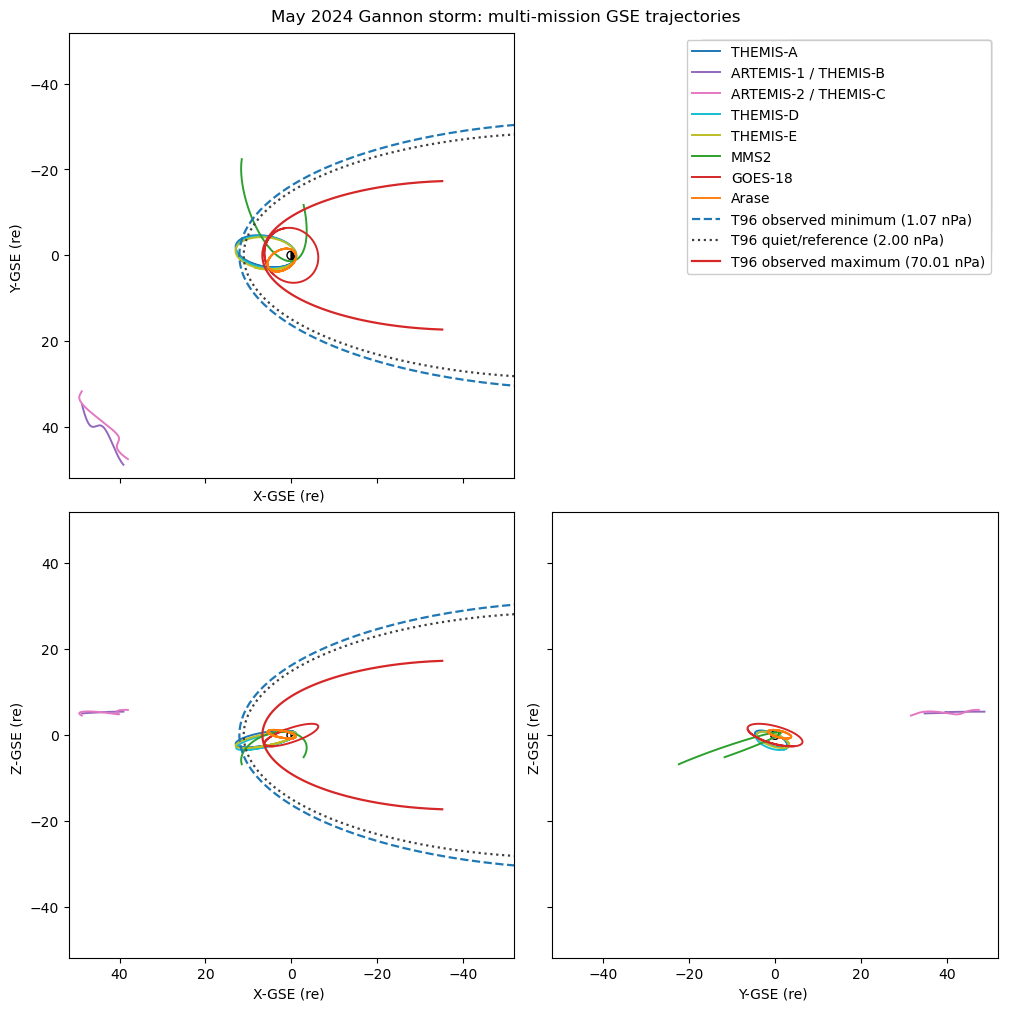

In [13]:
master_labels = list(orbit_vars_re)
master_vars = list(orbit_vars_re.values())

boundary_styles = {
    "observed minimum": ("tab:blue", "dashed"),
    "quiet/reference": ("0.25", "dotted"),
    "observed maximum": ("tab:red", "solid"),
}
fig = tplotxy3(
    master_vars,
    legend_names=master_labels,
    colors=["tab:blue", "tab:purple", "tab:pink", "tab:cyan",
            "tab:olive", "tab:green", "tab:red", "tab:orange"],
    linewidths=[1.4] * len(master_vars),
    reverse_x=True,
    plot_units="re",
    title="May 2024 Gannon storm: multi-mission GSE trajectories",
    #xrange=[-70, 25], yrange=[-45, 45], zrange=[-35, 35],
    display=False,
)

for label in ["observed minimum", "quiet/reference", "observed maximum"]:
    state = pressure_states[label]
    x_mp, rho_mp, _, _, _ = mpause_t96(state["pdyn"])
    color, linestyle = boundary_styles[label]
    tplotxy3_add_mpause(
        x_mp, rho_mp, fig=fig,
        legend_name=f"T96 {label} ({state['pdyn']:.2f} nPa)",
        color=color, linestyle=linestyle, linewidth=1.6,
        units="re", display=False,
    )

plt.show()

## 5. Event-focused geometry

For each teaching interval we create short orbit segments and model the magnetopause at the **median OMNI dynamic pressure within that interval**. The median is more representative than a single one-minute spike. The plot title reports the model pressure and the OMNI sample count.

The helper accepts a mission subset and fixed ranges. Lunar/ARTEMIS views use a wide range; the MMS, GOES-18, and Arase views use an inner-geospace zoom.

In [14]:
def subset_tplot_vector(source_name, trange, out_name):
    data = get_data(source_name)
    t0, t1 = time_double(trange)
    keep = (data.times >= t0) & (data.times <= t1)
    if not np.any(keep):
        return None
    store_data(out_name, data={"x": data.times[keep], "y": data.y[keep]})
    set_coords(out_name, "GSE")
    set_units(out_name, "Re")
    return out_name


def event_pressure(trange):
    t0, t1 = time_double(trange)
    keep = (
        (pressure.times >= t0) & (pressure.times <= t1)
        & np.isfinite(pressure.y) & (pressure.y > 0)
    )
    if not np.any(keep):
        raise ValueError(f"No valid OMNI Pressure samples in {trange}")
    return float(np.nanmedian(pressure.y[keep])), int(np.count_nonzero(keep))


def plot_event_geometry(event_name, missions, ranges):
    trange = events[event_name]
    segment_vars, labels = [], []
    slug = event_name.lower().replace(" ", "_").replace("/", "_")
    for mission in missions:
        source = orbit_vars_re[mission]
        out = subset_tplot_vector(source, trange, f"{source}_{slug}")
        if out is not None:
            segment_vars.append(out)
            labels.append(mission)

    if not segment_vars:
        raise RuntimeError(f"No orbit samples available for {event_name}")

    pdyn, count = event_pressure(trange)
    fig = tplotxy3(
        segment_vars,
        legend_names=labels,
        colors=["tab:blue", "tab:purple", "tab:green", "tab:red", "tab:orange"],
        linewidths=[2.2] * len(segment_vars),
        markers=["o"] * len(segment_vars),
        startmarkers=["^"] * len(segment_vars),
        endmarkers=["s"] * len(segment_vars),
        markevery=10,
        markersize=4,
        reverse_x=True,
        plot_units="re",
        title=(f"{event_name}: {trange[0]} to {trange[1]} UT; "
               f"median Pdyn={pdyn:.2f} nPa (N={count})"),
        xrange=ranges[0], yrange=ranges[1], zrange=ranges[2],
        display=False,
    )

    x_mp, rho_mp, _, _, _ = mpause_t96(pdyn)
    tplotxy3_add_mpause(
        x_mp, rho_mp, fig=fig,
        legend_name=f"T96 at median Pdyn = {pdyn:.2f} nPa",
        color="black", linestyle="solid", linewidth=1.8,
        units="re", display=False,
    )
    plt.show()
    return fig

01-Oct-26 11:41:35: Setting coordinate system for orbit_tha_pos_gse_re_themis_compression
01-Oct-26 11:41:35: Setting units for orbit_tha_pos_gse_re_themis_compression
01-Oct-26 11:41:35: Setting coordinate system for orbit_thd_pos_gse_re_themis_compression
01-Oct-26 11:41:35: Setting units for orbit_thd_pos_gse_re_themis_compression
01-Oct-26 11:41:35: Setting coordinate system for orbit_the_pos_gse_re_themis_compression
01-Oct-26 11:41:35: Setting units for orbit_the_pos_gse_re_themis_compression
01-Oct-26 11:41:35: Setting coordinate system for orbit_g18_orbit_xyz_gse_re_themis_compression
01-Oct-26 11:41:35: Setting units for orbit_g18_orbit_xyz_gse_re_themis_compression


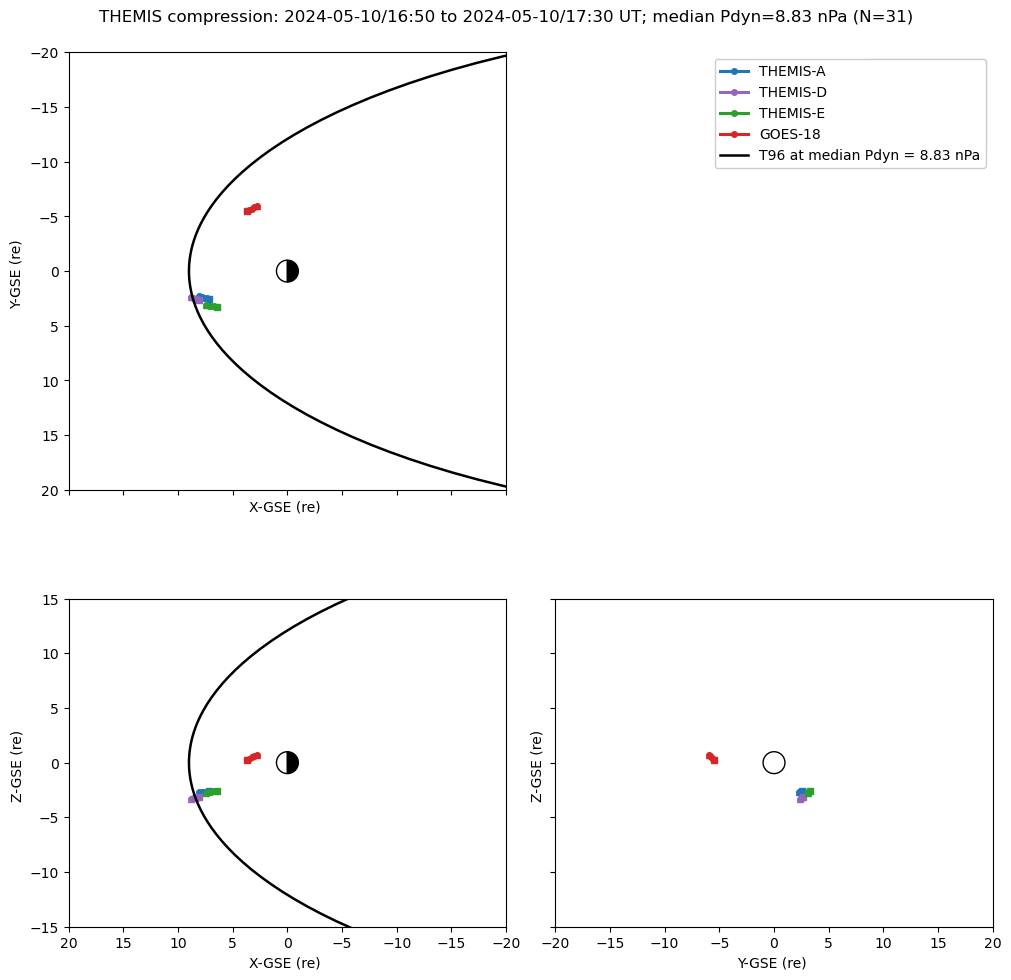

In [15]:
# Near-Earth compression: include the inner THEMIS probes and geosynchronous GOES-18.
fig_themis = plot_event_geometry(
    "THEMIS compression",
    ["THEMIS-A", "THEMIS-D", "THEMIS-E", "GOES-18"],
    ([-20, 20], [-20, 20], [-15, 15]),
)

01-Oct-26 11:41:44: Setting coordinate system for orbit_thb_pos_gse_re_artemis_boundary___imf_by
01-Oct-26 11:41:44: Setting units for orbit_thb_pos_gse_re_artemis_boundary___imf_by
01-Oct-26 11:41:44: Setting coordinate system for orbit_thc_pos_gse_re_artemis_boundary___imf_by
01-Oct-26 11:41:44: Setting units for orbit_thc_pos_gse_re_artemis_boundary___imf_by
01-Oct-26 11:41:44: Setting coordinate system for orbit_mms2_mec_r_gse_re_artemis_boundary___imf_by
01-Oct-26 11:41:44: Setting units for orbit_mms2_mec_r_gse_re_artemis_boundary___imf_by
01-Oct-26 11:41:44: Setting coordinate system for orbit_g18_orbit_xyz_gse_re_artemis_boundary___imf_by
01-Oct-26 11:41:44: Setting units for orbit_g18_orbit_xyz_gse_re_artemis_boundary___imf_by


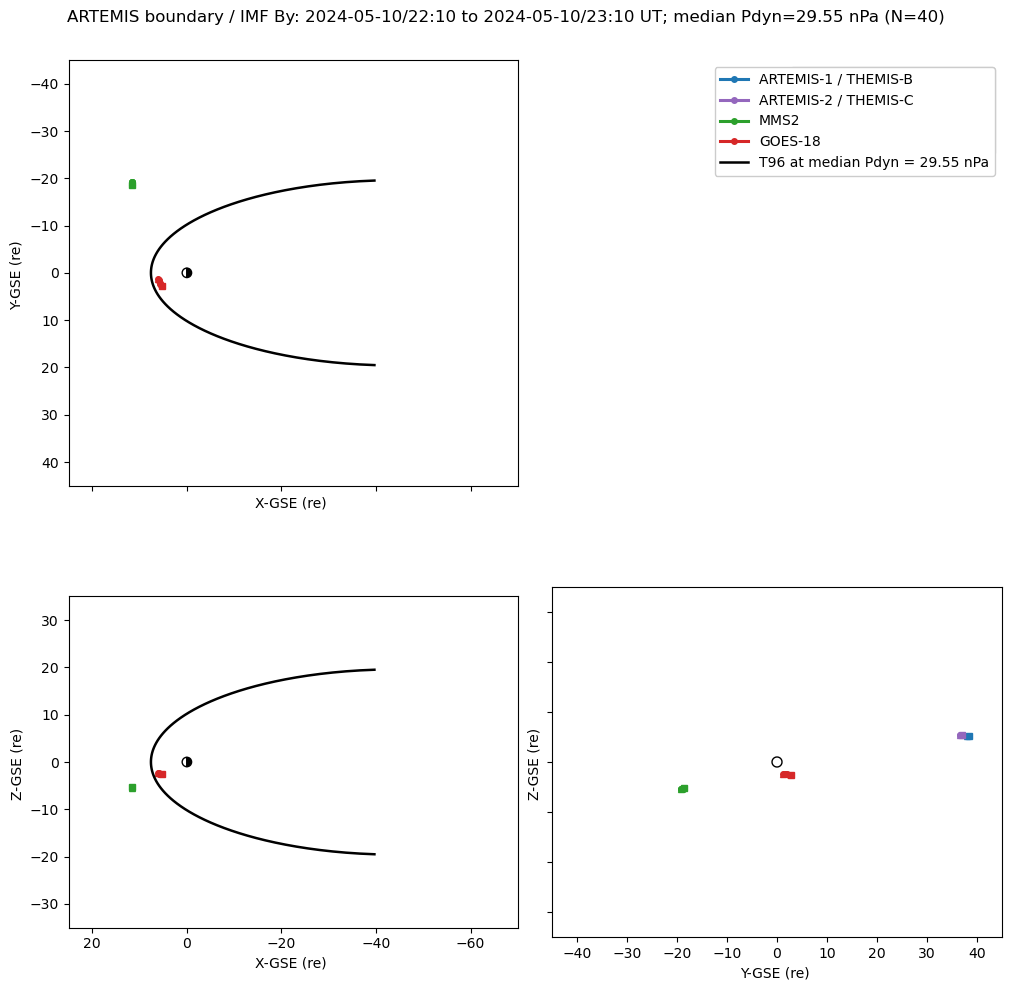

In [16]:
# Wide view: ARTEMIS is near lunar distance, while MMS and GOES-18 provide inner anchors.
fig_artemis = plot_event_geometry(
    "ARTEMIS boundary / IMF By",
    ["ARTEMIS-1 / THEMIS-B", "ARTEMIS-2 / THEMIS-C", "MMS2", "GOES-18"],
    ([-70, 25], [-45, 45], [-35, 35]),
)

01-Oct-26 11:41:50: Setting coordinate system for orbit_mms2_mec_r_gse_re_mms_dayside_crossing
01-Oct-26 11:41:50: Setting units for orbit_mms2_mec_r_gse_re_mms_dayside_crossing
01-Oct-26 11:41:50: Setting coordinate system for orbit_tha_pos_gse_re_mms_dayside_crossing
01-Oct-26 11:41:50: Setting units for orbit_tha_pos_gse_re_mms_dayside_crossing
01-Oct-26 11:41:50: Setting coordinate system for orbit_thd_pos_gse_re_mms_dayside_crossing
01-Oct-26 11:41:50: Setting units for orbit_thd_pos_gse_re_mms_dayside_crossing
01-Oct-26 11:41:50: Setting coordinate system for orbit_the_pos_gse_re_mms_dayside_crossing
01-Oct-26 11:41:50: Setting units for orbit_the_pos_gse_re_mms_dayside_crossing
01-Oct-26 11:41:50: Setting coordinate system for orbit_g18_orbit_xyz_gse_re_mms_dayside_crossing
01-Oct-26 11:41:50: Setting units for orbit_g18_orbit_xyz_gse_re_mms_dayside_crossing


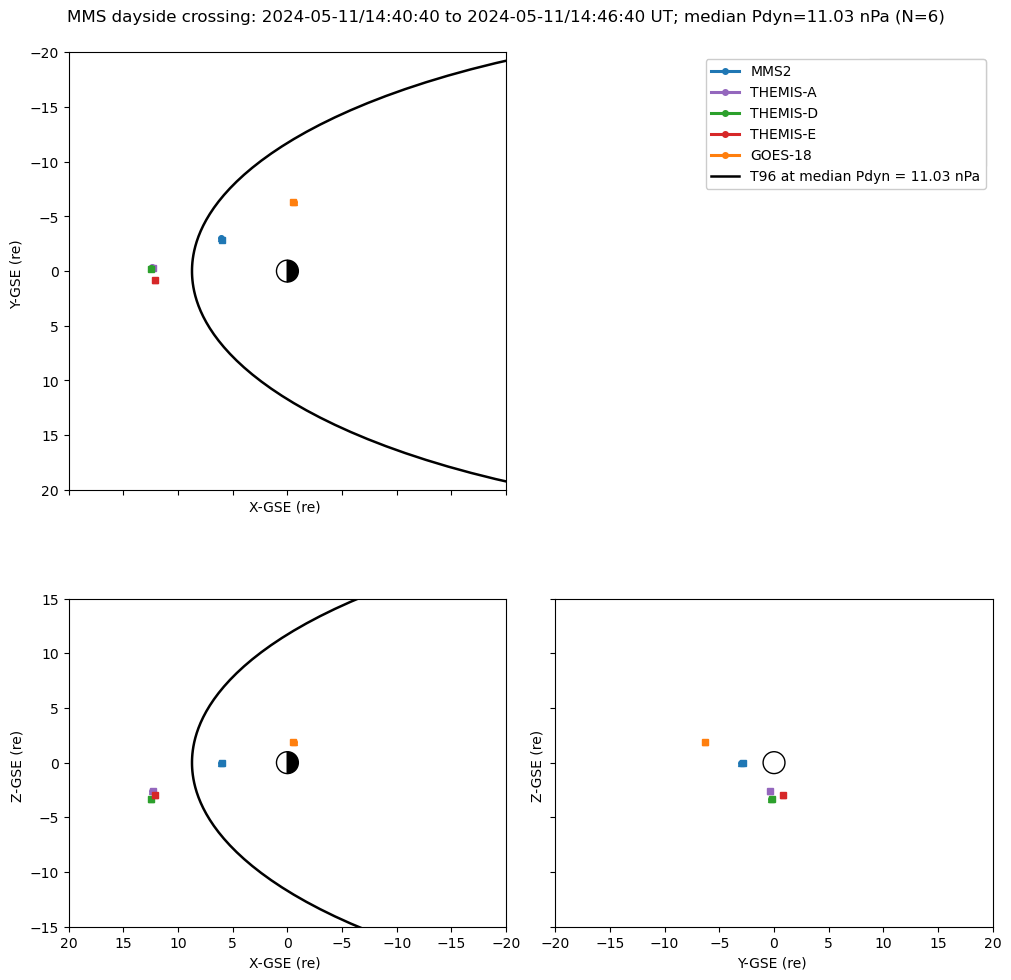

In [17]:
# Dayside reconnection geometry on 11 May.
fig_mms = plot_event_geometry(
    "MMS dayside crossing",
    ["MMS2", "THEMIS-A", "THEMIS-D", "THEMIS-E", "GOES-18"],
    ([-20, 20], [-20, 20], [-15, 15]),
)

01-Oct-26 11:41:59: Setting coordinate system for orbit_erg_orb_l2_pos_gse_re_arase_emic_waves
01-Oct-26 11:41:59: Setting units for orbit_erg_orb_l2_pos_gse_re_arase_emic_waves
01-Oct-26 11:41:59: Setting coordinate system for orbit_g18_orbit_xyz_gse_re_arase_emic_waves
01-Oct-26 11:41:59: Setting units for orbit_g18_orbit_xyz_gse_re_arase_emic_waves
01-Oct-26 11:41:59: Setting coordinate system for orbit_mms2_mec_r_gse_re_arase_emic_waves
01-Oct-26 11:41:59: Setting units for orbit_mms2_mec_r_gse_re_arase_emic_waves


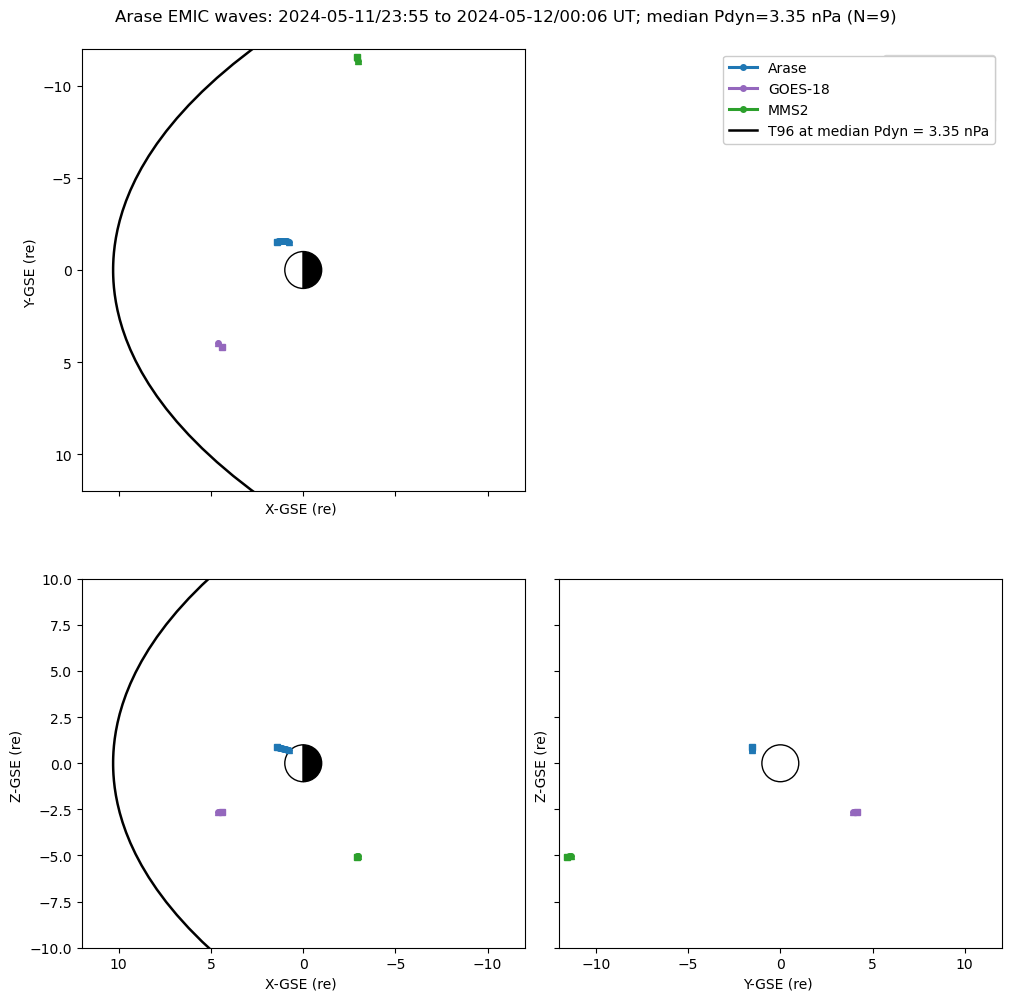

In [18]:
# Inner-magnetosphere wave context late on 11 May.
fig_arase = plot_event_geometry(
    "Arase EMIC waves",
    ["Arase", "GOES-18", "MMS2"],
    ([-12, 12], [-12, 12], [-10, 10]),
)

## 6. What the plots establish—and what they do not

Use the plots to discuss the following points:

- **Pressure matters strongly.** Compare the modeled subsolar stand-off distance at the observed minimum, 2 nPa reference, and observed maximum.
- **Cadence matters.** OMNI resolves rapid driving; Kp and Dst describe a slower, integrated geomagnetic response.
- **Geometry matters.** A similar time-series signature has a different interpretation at lunar distance, geosynchronous orbit, the dayside magnetopause, or deep in the inner magnetosphere.
- **The model is not the observation.** `mpause_t96` depends only on dynamic pressure and assumes a steady, rotationally symmetric boundary. It does not include IMF $B_Z$, reconnection erosion, dipole tilt, local-time asymmetry, boundary motion, or propagation uncertainty.
- **GSE versus GSM matters.** The overlay is suitable for an introductory geometry comparison because the pressure surface is axisymmetric. Any quantitative inside/outside classification should use GSM positions.

### Should we add model field-line traces?

Field-line traces add information that the magnetopause curves cannot: magnetic topology, whether a spacecraft is on a closed or open model line, approximate ionospheric conjugacy, and how field-line stretching changes from quiet to storm conditions. They are therefore useful—but best kept as a **separate optional exercise** for one or two representative times.

Tracing every orbit sample would overplot the figure and imply more model certainty than is warranted during this extreme storm. A focused extension could:

1. transform a few spacecraft positions from GSE to GSM;
2. select one quiet/reference time and one storm time;
3. call `pyspedas.geopack.ttrace2endpoint` with the T96 inputs `Pressure`, `kyoto_dst`, `BY_GSM`, and `BZ_GSM`; and
4. add only those traces to a new `tplotxy3` figure.

That exercise complements the boundary plot; it does not replace it. T96 field-line topology is also a model hypothesis, especially when the observed pressure and storm intensity are outside the model's best-tested regime.

### Other useful additions

- Calculate and print the subsolar stand-off distance for every pressure state.
- Compare OMNI GSE and GSM IMF components to make the coordinate transformation visible.
- Add a bow-shock curve to distinguish solar wind, magnetosheath, and magnetosphere.
- Ask students to identify which spacecraft can provide upstream timing, dayside boundary, geosynchronous, inner-magnetosphere, and lunar-tail context.
- As an advanced exercise, test time-shifting uncertainty by moving the OMNI driver a few minutes earlier and later.

In [19]:
# Compact quantitative summary for the discussion.
print("Approximate T96 subsolar stand-off distances")
for label, state in pressure_states.items():
    x_mp, rho_mp, _, _, _ = mpause_t96(state["pdyn"])
    # The nose is the boundary point with the largest X coordinate.
    nose = float(np.nanmax(x_mp))
    print(f"{label:18s}: Pdyn={state['pdyn']:6.2f} nPa, X_nose={nose:5.2f} Re")

Approximate T96 subsolar stand-off distances
observed minimum  : Pdyn=  1.07 nPa, X_nose=12.09 Re
quiet/reference   : Pdyn=  2.00 nPa, X_nose=11.08 Re
observed maximum  : Pdyn= 70.01 nPa, X_nose= 6.73 Re
